# Option Pricing via Simple Gaussian Distribution

We value options on a **chosen underlying** (set `ASSET` and `TARGET_DTE` in the config cell) using a **discretized terminal-price model**:

1. **Terminal distribution**: Gaussian centered at current spot, with standard deviation set from **2-month realized volatility** (annualized).
2. **Pricing equation**: Option price = discounted expected payoff = $e^{-rT} \sum_{\text{buckets}} \text{payoff}(S) \times P(S \text{ in bucket})$.
3. **Buckets**: Discretize the price axis into configurable buckets (e.g. bucket for 680 = [679.5, 680.5]); probability per bucket from the Gaussian CDF.
4. **Comparison**: Our implied prices vs current market mid for the same options.

---
## 1. Setup and data load

In [11]:
# --- Change these to analyze a different asset or expiry ---
ASSET = "SPY"        # underlying symbol (data: data/raw/{asset}_daily.parquet, chains in data/raw/option_chains/ or option_chains/{ASSET}/)
TARGET_DTE = 14    # None = auto-pick expiry (config band); else use expiry with DTE closest to this (e.g. 30, 45, 60)

In [12]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import SPY_DAILY_FILE, OPTION_CHAINS_DIR, RAW_DIR
from data.forecasts import load_chain_for_expiry

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


In [13]:
# Load underlying price series and get spot + 2-month realized vol (annualized)
price_file = SPY_DAILY_FILE if ASSET == "SPY" else RAW_DIR / f"{ASSET.lower()}_daily.parquet"
prices = pd.read_parquet(price_file)
prices.index = pd.to_datetime(prices.index).tz_localize(None)
prices = prices.sort_index()
prices["log_ret"] = np.log(prices["close"] / prices["close"].shift(1))
lookback = 21  # ~2 months trading days (used in next cell with as_of_date)

In [14]:
# Load option chain and set everything strictly as of the chain date (no future data)
chain_dir = OPTION_CHAINS_DIR if ASSET == "SPY" else OPTION_CHAINS_DIR / ASSET
chain_dates = sorted(set(
    f.stem.replace("calls_", "") for f in chain_dir.glob("calls_*.parquet")
    if (chain_dir / f"puts_{f.stem.replace('calls_','')}.parquet").exists()
))
date_str = chain_dates[-1] if chain_dates else None
as_of_date = pd.Timestamp(date_str)  # all inputs (spot, vol, options) are as of this date only
ref = as_of_date

# Spot and realized vol using only data on or before as_of_date (no leakage)
prices_as_of = prices.loc[prices.index <= as_of_date]
spot = float(prices_as_of["close"].iloc[-1])  # latest close on or before chain date
recent = prices_as_of["log_ret"].iloc[-lookback:].dropna()
realized_vol_annual = float(recent.std() * np.sqrt(252)) if len(recent) >= 2 else 0.15

print(f"As-of date: {as_of_date.date()} (chain date — no future data used)")
print(f"{ASSET} spot (close on as-of date): ${spot:.2f}")
print(f"2-month realized vol (annualized): {realized_vol_annual:.2%}")

# Optionally pick expiry by target DTE (closest to TARGET_DTE)
expiry_arg = None
if TARGET_DTE is not None and date_str:
    all_calls = pd.read_parquet(chain_dir / f"calls_{date_str}.parquet")
    all_calls.columns = [c.replace("impliedVolatility", "impl_vol").lower() for c in all_calls.columns]
    if "expiry" in all_calls.columns:
        expiries = sorted(all_calls["expiry"].unique())
        dte_list = [(e, (pd.Timestamp(e) - ref).days) for e in expiries if (pd.Timestamp(e) - ref).days > 0]
        if dte_list:
            expiry_arg = min(dte_list, key=lambda x: abs(x[1] - TARGET_DTE))[0]
            print(f"Target DTE={TARGET_DTE} → chosen expiry {expiry_arg} (DTE={(pd.Timestamp(expiry_arg) - ref).days})")

calls, puts, expiry_used = load_chain_for_expiry(chain_date=date_str, expiry=expiry_arg, underlying=ASSET)
exp_ts = pd.Timestamp(expiry_used)
T = max((exp_ts - ref).days / 365.0, 1e-4)
r = 0.05

print(f"Chain date: {date_str}   Expiry: {expiry_used}   T = {T:.4f} yrs   r = {r:.0%}")

As-of date: 2026-02-24 (chain date — no future data used)
SPY spot (close on as-of date): $687.35
2-month realized vol (annualized): 12.35%
Target DTE=14 → chosen expiry 2026-03-31 (DTE=35)
Chain date: 2026-02-24   Expiry: 2026-03-31   T = 0.0959 yrs   r = 5%


---
## 2. Gaussian terminal distribution and buckets

We assume terminal spot $S_T \sim \mathcal{N}(\mu=\text{spot}, \sigma_S)$ with $\sigma_S = \text{spot} \times \sigma_{\text{ann}} \sqrt{T}$ so the scale matches an annualized vol. Buckets are intervals of configurable width; probability in each bucket = CDF(right) - CDF(left).

In [15]:
# Configurable bucket grid
BUCKET_STEP = 1.0   # e.g. bucket 680 = [679.5, 680.5]
PRICE_RANGE_STDS = 4.0  # extend grid ± this many sigma_S from spot

mu = spot
sigma_S = spot * realized_vol_annual * np.sqrt(T)

half = PRICE_RANGE_STDS * sigma_S
centers = np.arange(mu - half, mu + half + BUCKET_STEP * 0.5, BUCKET_STEP)
centers = np.round(centers / BUCKET_STEP) * BUCKET_STEP
centers = np.unique(centers)

left_edges = centers - BUCKET_STEP / 2
right_edges = centers + BUCKET_STEP / 2
probs = norm.cdf((right_edges - mu) / sigma_S) - norm.cdf((left_edges - mu) / sigma_S)
probs = np.maximum(probs, 0.0)
probs /= probs.sum()

print(f"Bucket step: {BUCKET_STEP}   Centers: {len(centers)}   Prob sum: {probs.sum():.6f}")
print(f"mu = {mu:.2f}   sigma_S = {sigma_S:.2f}")

Bucket step: 1.0   Centers: 211   Prob sum: 1.000000
mu = 687.35   sigma_S = 26.29


---
## 3. Option valuation and comparison to market

**Units:** All option prices are **per share** (1 unit = 1 share). Chain mid is used as-is; we do not multiply or divide by 100.

For each option: **our_price** = $e^{-rT} \sum_b \text{payoff}(S_b) \, P(b)$ where payoff is call $\max(S-K,0)$ or put $\max(K-S,0)$ evaluated at bucket center $S_b$.

In [16]:
# All prices in this notebook are per share (1 unit = 1 share).
# Normalize quotes using no-arbitrage bounds; if a quote is inconsistent with per-share
# bounds but becomes consistent after dividing by 100, treat as per-contract and convert (and log).

strike_lo = float(centers.min())
strike_hi = float(centers.max())

# Bounds (per-share): loose no-arbitrage / sanity checks
# We deliberately use a **very weak** lower bound for calls so that deep ITM
# calls are not incorrectly dropped (American calls on dividend payers can
# trade below spot−strike). For puts we keep a stronger bound.
def bounds_per_share(K, spot, is_call, r, T):
    if is_call:
        # Only require non-negative price; cap at spot.
        lb = 0.0
        ub = spot
    else:
        # European-style put lower bound; tight upper bound at discounted strike.
        lb = max(0.0, K - spot)
        ub = K * np.exp(-r * T)
    return lb, ub

def to_per_share(mid, K, spot, is_call, r, T, expiry_used, conversion_log, tol=0.01):
    """One-way: assume per-share; only apply /100 when quote is clearly per-contract."""
    mid = float(mid)
    if np.isnan(mid) or mid <= 0:
        return np.nan
    lb, ub = bounds_per_share(K, spot, is_call, r, T)
    # In bounds (with tolerance)?
    in_bounds = (lb - tol <= mid <= ub + tol)
    if in_bounds:
        return mid
    # Below lower bound: no /100 fix (one-way only); flag and drop
    if mid < lb - tol:
        conversion_log.append({
            "symbol": ASSET, "expiry": expiry_used, "strike": K, "spot": spot,
            "raw_mid": mid, "rule": "below_lb_unresolved", "per_share": np.nan,
        })
        return np.nan
    # Above upper bound by large factor? Try per-contract (/100).
    if mid > 5.0 * ub:
        candidate = mid / 100.0
        if (lb - tol <= candidate <= ub + tol):
            conversion_log.append({
                "symbol": ASSET, "expiry": expiry_used, "strike": K, "spot": spot,
                "raw_mid": mid, "rule": "mid > 5*ub → /100", "per_share": candidate,
            })
            return candidate
    # Cannot resolve: keep original but flag (return NaN so we skip this row)
    conversion_log.append({
        "symbol": ASSET, "expiry": expiry_used, "strike": K, "spot": spot,
        "raw_mid": mid, "rule": "out_of_bounds_unresolved", "per_share": np.nan,
    })
    return np.nan

conversion_log = []

def payoff_call(S_center, K):
    return np.maximum(S_center - K, 0.0)

def payoff_put(S_center, K):
    return np.maximum(K - S_center, 0.0)

def our_option_price(centers, probs, K, is_call, r, T):
    payoffs = payoff_call(centers, K) if is_call else payoff_put(centers, K)
    return np.exp(-r * T) * np.sum(payoffs * probs)

df_list = []
for _, row in calls.iterrows():
    K = float(row["strike"])
    if K < strike_lo or K > strike_hi:
        continue
    mid = to_per_share(row["mid"], K, spot, True, r, T, expiry_used, conversion_log)
    if np.isnan(mid):
        continue
    ours = our_option_price(centers, probs, K, True, r, T)
    df_list.append({"strike": K, "type": "call", "market_mid": mid, "our_price": ours})

for _, row in puts.iterrows():
    K = float(row["strike"])
    if K < strike_lo or K > strike_hi:
        continue
    mid = to_per_share(row["mid"], K, spot, False, r, T, expiry_used, conversion_log)
    if np.isnan(mid):
        continue
    ours = our_option_price(centers, probs, K, False, r, T)
    df_list.append({"strike": K, "type": "put", "market_mid": mid, "our_price": ours})

compare = pd.DataFrame(df_list)
compare["diff"] = compare["our_price"] - compare["market_mid"]
compare["diff_pct"] = compare["diff"] / compare["market_mid"].replace(0, np.nan)
# Drop nonsensical rows: we value near 0 but market is huge (wrong units or outside model range)
n_before = len(compare)
compare = compare[~((compare["our_price"] < 1.0) & (compare["market_mid"] > 100.0))].copy()
n_dropped = n_before - len(compare)
if n_dropped:
    print(f"Dropped {n_dropped} outlier(s): our_price < 1 and market_mid > 100\n")
n_convert = sum(1 for e in conversion_log if e.get("rule", "").startswith("mid > 5"))
n_bad = sum(1 for e in conversion_log if "unresolved" in str(e.get("rule", "")))
if conversion_log:
    print(f"Conversions: {n_convert} applied /100 (per-contract→per-share); {n_bad} unresolved (dropped)\n")
    for e in conversion_log[:10]:
        print(f"  {e['symbol']} expiry={e['expiry']} K={e['strike']} spot={e['spot']} raw_mid={e['raw_mid']} → {e['rule']} → {e['per_share']}")
    if len(conversion_log) > 10:
        print(f"  ... and {len(conversion_log) - 10} more\n")
print(f"Strike range used: [{strike_lo:.0f}, {strike_hi:.0f}] (only options we can value)\n")
print(compare.head(12).to_string())

Conversions: 0 applied /100 (per-contract→per-share); 15 unresolved (dropped)

  SPY expiry=2026-03-31 K=724.0 spot=687.35 raw_mid=36.605000000000004 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=728.0 spot=687.35 raw_mid=40.495 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=732.0 spot=687.35 raw_mid=44.55 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=734.0 spot=687.35 raw_mid=46.31 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=736.0 spot=687.35 raw_mid=48.254999999999995 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=737.0 spot=687.35 raw_mid=49.49 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=738.0 spot=687.35 raw_mid=50.56 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=739.0 spot=687.35 raw_mid=51.215 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=740.0 spot=687.35 raw_mid=52.105000000000004 → below_lb_unresolved → nan
  SPY expiry=2026-03-31 K=742.0 spot=687.35 raw_mid=54.465 → below_lb_unresolved → nan
  ... and 5 more

S

---
## 4. Gaussian mixture model (least-squares fit)

**One distribution, not 200.** We model **one** random variable: **terminal spot $S_T$** (the stock price at expiry). There is **one** distribution for $S_T$, which we take to be a 4-component Gaussian mixture. We do **not** fit a separate GMM per option or per strike — every option in the chain is a contract on the **same** $S_T$.

**How do the ~200 options get used?** They are **many views** on that single $S_T$: each option has a payoff that is a function of $S_T$ (e.g. call with strike $K$ pays $\max(S_T - K, 0)$). So we have one unknown distribution (the 4 mixture weights) and ~200 observed market prices. We **fit the one GMM** by choosing the 4 weights so that the **model prices** (expected payoff under that GMM, discounted) match the **market mids** as well as possible in least-squares sense. So: **one GMM for $S_T$**, fitted using all option prices. Once we have it, we can sample $S_T$ from that single GMM and value (or get returns for) any option we like; for the 4-asset portfolio we only report returns for one call and one put (ATM).

**Mixture form:** P(S) = w₁·N₁ + w₂·N₂ + w₃·N₃ + w₄·N₄ with weights w ≥ 0, Σw = 1:

1. **G1**: μ = spot, σ = σ_S (2-month realized vol scale)
2. **G2**: μ = spot, σ = 2σ_S (wider Gaussian at spot)
3. **G3**: μ = spot + σ_S (shifted right)
4. **G4**: μ = spot − σ_S (shifted left)

We minimize Σ(model_price − market_mid)² over the weights using all options in `compare`. The CV sections below check robustness to different subsets of options.

In [17]:
# Build bucket probabilities for each of the 4 Gaussians (same grid as before)
def gaussian_probs_on_grid(centers, left_edges, right_edges, mu, sigma):
    p = norm.cdf((right_edges - mu) / sigma) - norm.cdf((left_edges - mu) / sigma)
    p = np.maximum(p, 0.0)
    return p / p.sum()

# G1: spot, sigma_S (realized vol)
# G2: spot, 2*sigma_S (wider)
# G3: spot + sigma_S, sigma_S (shifted right)
# G4: spot - sigma_S, sigma_S (shifted left)
probs_g1 = gaussian_probs_on_grid(centers, left_edges, right_edges, spot, sigma_S)
probs_g2 = gaussian_probs_on_grid(centers, left_edges, right_edges, spot, 2.0 * sigma_S)
probs_g3 = gaussian_probs_on_grid(centers, left_edges, right_edges, spot + sigma_S, sigma_S)
probs_g4 = gaussian_probs_on_grid(centers, left_edges, right_edges, spot - sigma_S, sigma_S)

# Mixture price: exp(-rT) * E[payoff] under P_mix = w1*p1 + w2*p2 + w3*p3 + w4*p4
def mixture_option_price(centers, probs_list, weights, K, is_call, r, T):
    probs_mix = sum(w * p for w, p in zip(weights, probs_list))
    probs_mix = probs_mix / probs_mix.sum()
    payoffs = payoff_call(centers, K) if is_call else payoff_put(centers, K)
    return np.exp(-r * T) * np.sum(payoffs * probs_mix)

# Fit weights: min sum (model_price - market_mid)^2, w >= 0, sum(w) = 1
# Use softmax parametrization: w = exp(x) / sum(exp(x)) for unconstrained x
probs_list = [probs_g1, probs_g2, probs_g3, probs_g4]

def obj(x):
    w = np.exp(x) / np.exp(x).sum()
    sse = 0.0
    for _, row in compare.iterrows():
        K, is_call = row["strike"], (row["type"] == "call")
        model_p = mixture_option_price(centers, probs_list, w, K, is_call, r, T)
        sse += (model_p - row["market_mid"]) ** 2
    return sse

res = minimize(obj, x0=np.zeros(4), method="Nelder-Mead", options={"maxiter": 5000})
w_fit = np.exp(res.x) / np.exp(res.x).sum()
w_fit = np.maximum(w_fit, 1e-8)  # avoid zeros
w_fit /= w_fit.sum()

print("Fitted mixture weights:")
for i, (name, wi) in enumerate(zip(["G1(spot,σ)", "G2(spot,2σ)", "G3(spot+σ,σ)", "G4(spot-σ,σ)"], w_fit)):
    print(f"  {name}: {wi:.3f}")
print(f"  SSE: {res.fun:.2f}")

# Add mixture prices to comparison
compare["mix_price"] = [
    mixture_option_price(centers, probs_list, w_fit, row["strike"], row["type"] == "call", r, T)
    for _, row in compare.iterrows()
]
compare["mix_diff"] = compare["mix_price"] - compare["market_mid"]
compare["mix_diff_pct"] = compare["mix_diff"] / compare["market_mid"].replace(0, np.nan)

print("\nSingle Gaussian vs Mixture (RMSE vs market):")
print(f"  Single: {np.sqrt(((compare['our_price'] - compare['market_mid'])**2).mean()):.3f}")
print(f"  Mixture: {np.sqrt(((compare['mix_price'] - compare['market_mid'])**2).mean()):.3f}")
print("\nSample (first 10):")
print(compare[["strike", "type", "market_mid", "our_price", "mix_price", "mix_diff_pct"]].head(10).to_string())

Fitted mixture weights:
  G1(spot,σ): 0.550
  G2(spot,2σ): 0.355
  G3(spot+σ,σ): 0.095
  G4(spot-σ,σ): 0.000
  SSE: 855.62

Single Gaussian vs Mixture (RMSE vs market):
  Single: 3.307
  Mixture: 1.783

Sample (first 10):
   strike  type  market_mid   our_price   mix_price  mix_diff_pct
0   585.0  call     105.790  101.860133  104.320515     -0.013891
1   586.0  call     104.740  100.864941  103.326907     -0.013491
2   590.0  call     100.045   96.884278   99.357073     -0.006876
3   595.0  call      93.925   91.908836   94.406504      0.005126
4   600.0  call      89.785   86.934212   89.471396     -0.003493
5   605.0  call      86.275   81.961146   84.554800     -0.019939
6   610.0  call      80.705   76.990950   79.660365     -0.012944
7   615.0  call      76.865   72.025850   74.792515     -0.026963
8   620.0  call      71.150   67.069478   69.956705     -0.016772
9   621.0  call      68.945   66.079708   68.993960      0.000710


In [24]:
# Improved flexible GMM fit: free means/variances, more components, IV-based widths

N_COMPONENTS = 4


def _component_probs(centers, left_edges, right_edges, mus, sigmas):
    """Bucket probabilities for each Gaussian component on the fixed grid."""
    probs_list = []
    for mu_c, sig_c in zip(mus, sigmas):
        sig_safe = max(sig_c, 1e-10)
        p = norm.cdf((right_edges - mu_c) / sig_safe) - norm.cdf((left_edges - mu_c) / sig_safe)
        p = np.maximum(p, 0.0)
        p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
        s = p.sum()
        p = p / s if s > 1e-20 else (np.ones_like(p) / len(p))
        probs_list.append(p)
    return probs_list


# Use ATM implied volatility (if available) to set initial spot-space sigma
if len(calls) == 0:
    iv_atm = realized_vol_annual
else:
    atm_idx = (calls["strike"] - spot).abs().idxmin()
    atm_call = calls.loc[atm_idx]
    iv_atm = float(atm_call.get("impl_vol", np.nan))
    if not np.isfinite(iv_atm) or iv_atm <= 0:
        iv_atm = realized_vol_annual  # fallback to realized vol

sigma_S_iv = spot * iv_atm * np.sqrt(T)

# Initial guesses for component means (left-skewed) and sigmas
mu_init = spot + sigma_S_iv * np.array([-2.0, -1.0, -0.3, 0.0, 0.7, 1.5])
sigma_init = sigma_S_iv * np.array([2.0, 1.5, 1.0, 1.0, 1.2, 1.5])


MIN_SIGMA = 10.0  # minimum terminal-price sigma to avoid pathological spikes
MAX_SIGMA = max(sigma_init) * 4  # cap width so no component is absurdly wide (e.g. 485M)
MIN_MU = spot * 0.85  # component means at least 15% below spot (experiment)


def _unpack_params(x):
    mus = x[:N_COMPONENTS]
    mus = np.maximum(mus, MIN_MU)
    log_sig = np.clip(x[N_COMPONENTS:2 * N_COMPONENTS], np.log(MIN_SIGMA), np.log(MAX_SIGMA))
    sigmas_raw = np.exp(log_sig)
    sigmas = np.clip(sigmas_raw, MIN_SIGMA, MAX_SIGMA)
    logits = x[2 * N_COMPONENTS : 3 * N_COMPONENTS]
    w = np.exp(logits - logits.max())
    w /= w.sum()
    return mus, sigmas, w


def mixture_option_price(centers, probs_list, weights, K, is_call, r, T):
    """Mixture price: exp(-rT) * E[payoff] under P_mix = Σ w_j p_j."""
    probs_mix = sum(w * p for w, p in zip(weights, probs_list))
    probs_mix = probs_mix / probs_mix.sum()
    payoffs = payoff_call(centers, K) if is_call else payoff_put(centers, K)
    return np.exp(-r * T) * np.sum(payoffs * probs_mix)


def obj_flexible(x):
    mus, sigmas, w = _unpack_params(x)
    probs_list_local = _component_probs(centers, left_edges, right_edges, mus, sigmas)
    sse = 0.0
    for _, row in compare.iterrows():
        K, is_call = row["strike"], (row["type"] == "call")
        model_p = mixture_option_price(centers, probs_list_local, w, K, is_call, r, T)
        sse += (model_p - row["market_mid"]) ** 2
    return sse

x0 = np.concatenate([
    mu_init,
    np.log(sigma_init),
    np.zeros(N_COMPONENTS),  # logits for weights (start uniform)
])

res_flex = minimize(obj_flexible, x0=x0, method="Nelder-Mead", options={"maxiter": 8000})
mu_fit, sigma_fit, w_fit = _unpack_params(res_flex.x)

# Rebuild final probability lists with fitted parameters
probs_list = _component_probs(centers, left_edges, right_edges, mu_fit, sigma_fit)

print("Fitted mixture (flexible GMM):")
for j, (mu_j, sig_j, w_j) in enumerate(zip(mu_fit, sigma_fit, w_fit)):
    print(f"  Comp {j+1}: mu={mu_j:.2f}, sigma={sig_j:.2f}, weight={w_j:.3f}")
print(f"  SSE: {res_flex.fun:.2f}")

# Store for sampling section
means_gmm = mu_fit.copy()
sigmas_gmm = sigma_fit.copy()

# Add mixture prices to comparison (overwrite previous mix_price if any)
compare["mix_price"] = [
    mixture_option_price(centers, probs_list, w_fit, row["strike"], row["type"] == "call", r, T)
    for _, row in compare.iterrows()
]
compare["mix_diff"] = compare["mix_price"] - compare["market_mid"]
compare["mix_diff_pct"] = compare["mix_diff"] / compare["market_mid"].replace(0, np.nan)

print("\nSingle Gaussian vs flexible GMM (RMSE vs market):")
print(f"  Single: {np.sqrt(((compare['our_price'] - compare['market_mid'])**2).mean()):.3f}")
print(f"  Flexible GMM: {np.sqrt(((compare['mix_price'] - compare['market_mid'])**2).mean()):.3f}")
print("\nSample (first 10):")
print(compare[["strike", "type", "market_mid", "our_price", "mix_price", "mix_diff_pct"]].head(10).to_string())


Fitted mixture (flexible GMM):
  Comp 1: mu=1135.62, sigma=260.01, weight=0.000
  Comp 2: mu=584.25, sigma=10.00, weight=0.000
  Comp 3: mu=584.25, sigma=117.04, weight=0.330
  Comp 4: mu=701.00, sigma=10.00, weight=0.670
  SSE: 165.84

Single Gaussian vs flexible GMM (RMSE vs market):
  Single: 3.307
  Flexible GMM: 0.785

Sample (first 10):
   strike  type  market_mid   our_price   mix_price  mix_diff_pct
0   585.0  call     105.790  101.860133  102.951238     -0.026834
1   586.0  call     104.740  100.864941  101.965501     -0.026489
2   590.0  call     100.045   96.884278   98.046248     -0.019979
3   595.0  call      93.925   91.908836   93.200432     -0.007714
4   600.0  call      89.785   86.934212   88.413612     -0.015274
5   605.0  call      86.275   81.961146   83.685504     -0.030014
6   610.0  call      80.705   76.990950   79.015718     -0.020932
7   615.0  call      76.865   72.025850   74.403761     -0.032020
8   620.0  call      71.150   67.069478   69.849040     -0.01

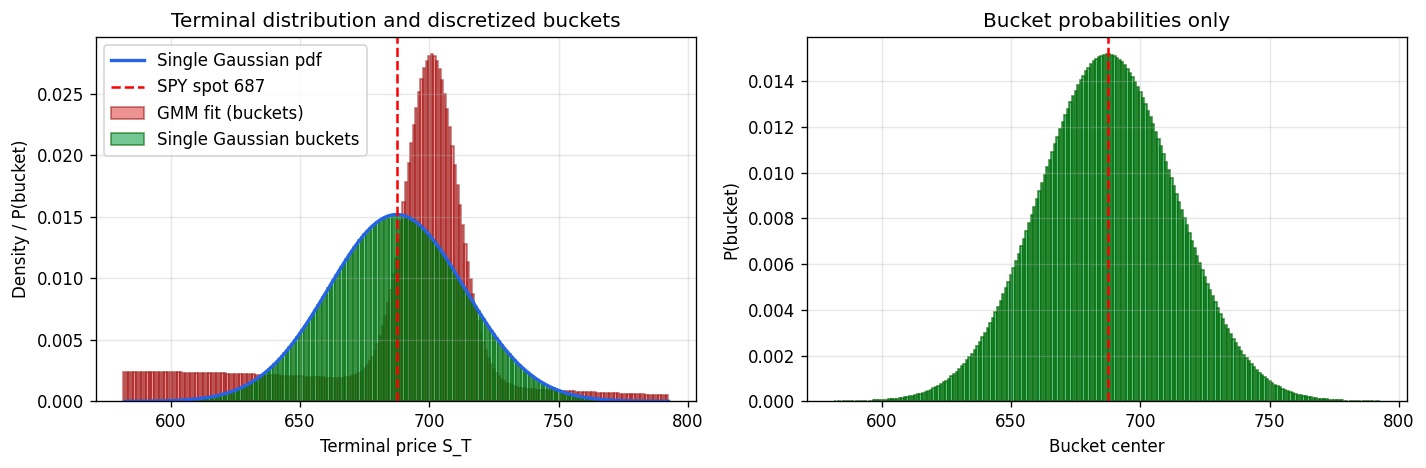

In [25]:
# 1) Gaussian PDF and bucket probabilities
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(mu - 4 * sigma_S, mu + 4 * sigma_S, 300)
axes[0].plot(x, norm.pdf(x, mu, sigma_S), color="#2563eb", linewidth=2, label="Single Gaussian pdf")
try:
    probs_mix = sum(w * p for w, p in zip(w_fit, probs_list))
    probs_mix = probs_mix / probs_mix.sum()
    axes[0].bar(centers, probs_mix, width=BUCKET_STEP * 0.85, alpha=0.5, color="#dc2626", edgecolor="darkred", label="GMM fit (buckets)")
except NameError:
    pass  # GMM cell not run yet
axes[0].bar(centers, probs, width=BUCKET_STEP * 0.9, alpha=0.6, color="#16a34a", edgecolor="darkgreen", label="Single Gaussian buckets")
axes[0].axvline(spot, color="red", linestyle="--", linewidth=1.5, label=f"{ASSET} spot {spot:.0f}")
axes[0].set_xlabel("Terminal price S_T")
axes[0].set_ylabel("Density / P(bucket)")
axes[0].set_title("Terminal distribution and discretized buckets")
axes[0].legend()

axes[1].bar(centers, probs, width=BUCKET_STEP * 0.9, alpha=0.7, color="#16a34a", edgecolor="darkgreen")
axes[1].axvline(spot, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Bucket center")
axes[1].set_ylabel("P(bucket)")
axes[1].set_title("Bucket probabilities only")
plt.tight_layout()
plt.show()

### 4.1 GMM cross-validation over strikes

To test **robustness** of the fitted flexible 6-component Gaussian mixture, we run **K=5 fold cross-validation** over the option table (calls + puts). Each option is assigned to exactly one fold (0–4) via a fixed random permutation (seeded RNG), so every contract is held out **exactly once**.

**What is used to build the distribution (train set)**  
For fold k, the **training set** is all options **not** in fold k (the other 4 folds, ~80% of data). We keep the **component means and variances** fixed at the values learned from the full-sample flexible GMM, and re-fit **only the mixture weights** on the training subset by minimizing squared error between model price and market mid. So the overall *shape* of the terminal distribution (skew, tails) is shared across folds; the per-fold weights are a mild re-tuning.

**What is held out (validation set)**  
The **held-out set** for fold k is exactly the options in fold k (~20% of the data). We **do not** use these when fitting that fold’s weights. We only: (1) take the flexible GMM components + weights trained on the other folds, (2) price each held-out option with that model, (3) compare that “GMM price (train fit)” to market mid. Each panel in the figure below shows one fold’s **held-out options only**: x = market mid, y = GMM price from the model trained on the other four folds.

**Why do all folds look similar?**  
Because the option surface is smooth and the same 6-component structure is used every time (same μ/σ, slightly different weights), different train subsets produce very similar fits, so held-out predictions look similar across folds. That **consistency** is what we want: it suggests the approach is robust to which strikes we leave out. If one fold looked much worse than the others, we’d worry about sensitivity to the split or a bad luck hold-out set.

GMM cross-validation over strikes (K-fold, random partition; each option held out once):
 fold  n_val  rmse_gaussian_val  rmse_mix_val
    0     54           3.161832      0.664397
    1     54           3.128624      0.960499
    2     54           3.312306      0.656449
    3     54           3.543808      0.604805
    4     53           3.371810      0.683605

Average validation RMSE across folds:
                   mean_RMSE
rmse_gaussian_val   3.303676
rmse_mix_val        0.713951

Mixture weight stability across folds (mean ± std):
          mean     std
Comp 1  0.1704  0.0016
Comp 2  0.1451  0.0129
Comp 3  0.2712  0.0790
Comp 4  0.0402  0.0640
Comp 5  0.2683  0.0992
Comp 6  0.1048  0.1419


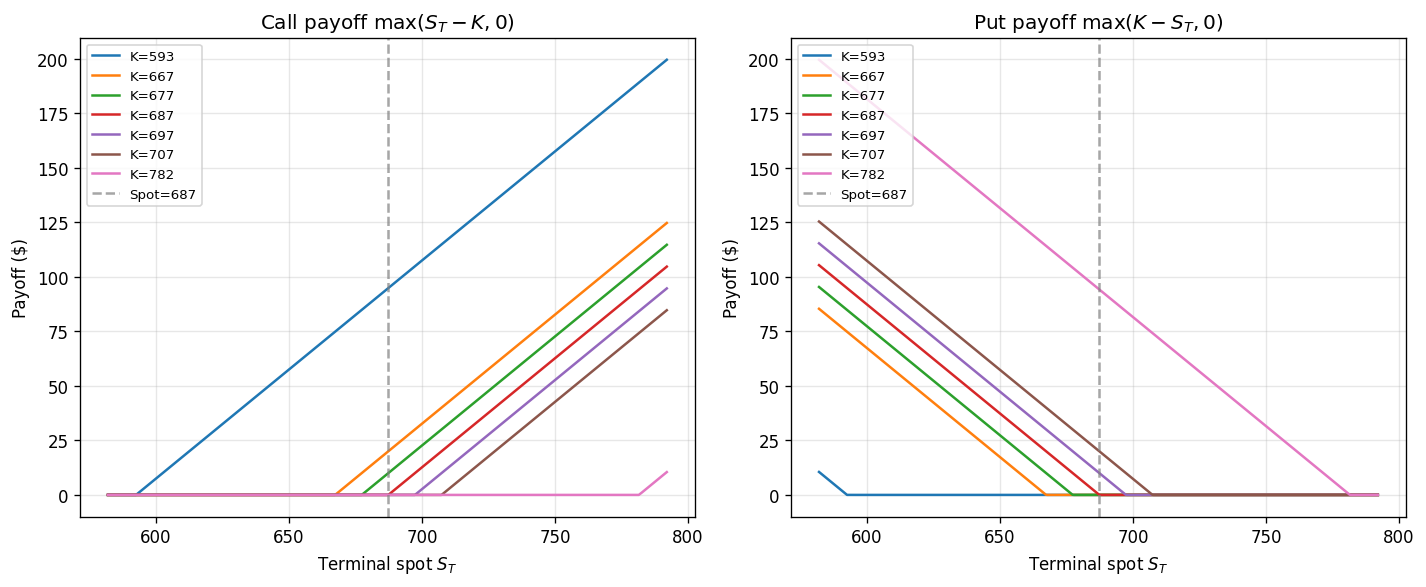

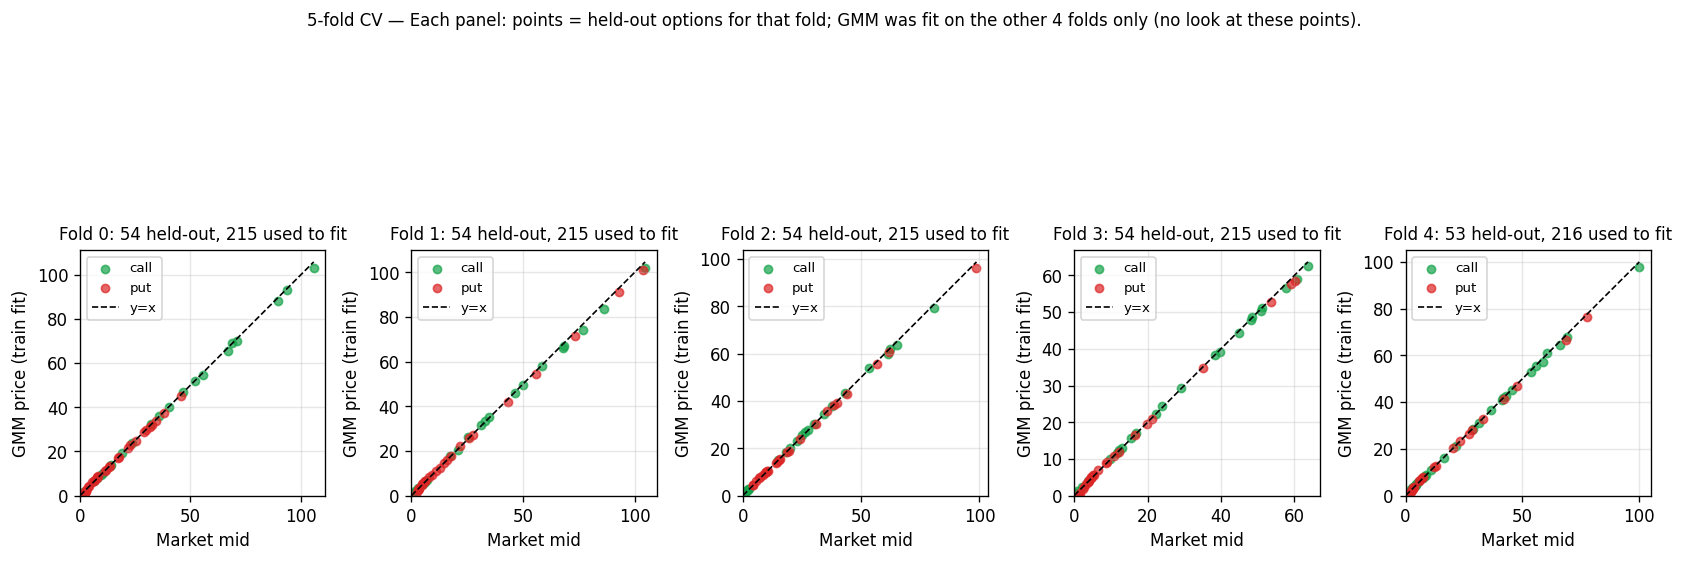

Similarity across folds is expected: the same flexible 6-component structure fits different train subsets similarly, so validation looks consistent (robust).


In [ ]:
# 4.1 GMM cross-validation over strikes (K-fold, using flexible GMM, random folds)
K_folds = 5
compare_cv = compare.sort_values(["type", "strike"]).reset_index(drop=True).copy()

# Randomized K-fold: each option is held out exactly once
rng = np.random.default_rng(42)
perm = rng.permutation(len(compare_cv))
fold_ids = perm % K_folds


def _fit_gmm_weights_on_subset(train_df):
    """Refit mixture weights on a subset, keeping flexible-GMM components fixed.

    We reuse the fitted component means/sigmas (mu_fit, sigma_fit) from the
    flexible GMM above, and only adjust the mixture weights w on each fold.
    """

    def obj_local(x):
        # x has shape (N_COMPONENTS,) → softmax to get weights
        w = np.exp(x - x.max())
        w /= w.sum()
        # Rebuild probabilities once per x
        probs_list_local = _component_probs(centers, left_edges, right_edges, mu_fit, sigma_fit)
        sse = 0.0
        for _, row in train_df.iterrows():
            K_, is_call = row["strike"], (row["type"] == "call")
            model_p = mixture_option_price(centers, probs_list_local, w, K_, is_call, r, T)
            sse += (model_p - row["market_mid"]) ** 2
        return sse

    x0 = np.zeros(N_COMPONENTS)
    res = minimize(obj_local, x0=x0, method="Nelder-Mead", options={"maxiter": 3000})
    logits = res.x
    w = np.exp(logits - logits.max())
    w /= w.sum()
    w = np.maximum(w, 1e-8)
    w /= w.sum()
    return w

rows = []
w_list = []
val_dfs = []  # per-fold validation df with mix_price_val for plotting
for k in range(K_folds):
    train_df = compare_cv[fold_ids != k]
    val_df = compare_cv[fold_ids == k].copy()
    if len(val_df) == 0:
        continue
    w_k = _fit_gmm_weights_on_subset(train_df)
    w_list.append(w_k)

    rmse_gauss = float(np.sqrt(((val_df["our_price"] - val_df["market_mid"]) ** 2).mean()))
    mix_val_prices = [
        mixture_option_price(centers, probs_list, w_k, row["strike"], row["type"] == "call", r, T)
        for _, row in val_df.iterrows()
    ]
    val_df["mix_price_val"] = mix_val_prices
    val_dfs.append(val_df)
    rmse_mix = float(np.sqrt(((np.array(mix_val_prices) - val_df["market_mid"].values) ** 2).mean()))

    rows.append({"fold": k, "n_val": len(val_df), "rmse_gaussian_val": rmse_gauss, "rmse_mix_val": rmse_mix})

cv_df = pd.DataFrame(rows)
print("GMM cross-validation over strikes (K-fold, random partition; each option held out once):")
print(cv_df.to_string(index=False))

print("\nAverage validation RMSE across folds:")
print(cv_df[["rmse_gaussian_val", "rmse_mix_val"]].mean().to_frame("mean_RMSE").to_string())

if w_list:
    w_mat = np.vstack(w_list)
    comp_index = [f"Comp {j+1}" for j in range(N_COMPONENTS)]
    w_summary = pd.DataFrame(
        {"mean": w_mat.mean(axis=0), "std": w_mat.std(axis=0)},
        index=comp_index,
    )
    print("\nMixture weight stability across folds (mean ± std):")
    print(w_summary.round(4).to_string())

# Five panels: each shows held-out options for one fold — GMM price (fit on train) vs market mid
n_total = len(compare_cv)
fig_cv, axes = plt.subplots(1, 5, figsize=(14, 5.5))
for k, ax in enumerate(axes):
    v = val_dfs[k]
    n_train = n_total - len(v)
    for opt_type, color in [("call", "#16a34a"), ("put", "#dc2626")]:
        sub = v[v["type"] == opt_type]
        if len(sub) > 0:
            ax.scatter(sub["market_mid"], sub["mix_price_val"], alpha=0.7, s=24, c=color, label=opt_type)
    mx = max(v["market_mid"].max(), v["mix_price_val"].max()) if len(v) > 0 else 1
    ax.plot([0, mx], [0, mx], "k--", linewidth=1, label="y=x")
    ax.set_xlabel("Market mid")
    ax.set_ylabel("GMM price (train fit)")
    ax.set_title(f"Fold {k}: {len(v)} held-out, {n_train} used to fit", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_aspect("equal")
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
plt.suptitle(
    "5-fold CV — Each panel: points = held-out options for that fold; "
    "GMM was fit on the other 4 folds only (no look at these points).",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()
print("Similarity across folds is expected: the same flexible 6-component structure fits different train subsets similarly, so validation looks consistent (robust).")

### 4.2 Blocked strike CV (contiguous moneyness bins)

Hold out **contiguous strike buckets** (e.g. 5 bins by strike): options are sorted by strike and split into 5 consecutive segments. For each fold we hold out one segment and fit the GMM on the other four. This tests whether the model can price **wings** (far OTM/ITM) from **ATM** information when we hold out an entire strike region.

- **Train set:** All options whose strike falls in the other 4 bins (~80%).
- **Held-out set:** All options in one bin (~20%) — e.g. fold 0 = lowest strikes (put wing), fold 2 ≈ ATM, fold 4 = highest strikes (call wing).

Blocked strike CV (5 contiguous strike bins):
 fold  n_val  rmse_gaussian_val  rmse_mix_val
    0     53           3.534875      1.324679
    1     53           4.818857      0.452436
    2     53           4.247826      0.217496
    3     53           1.211181      0.290037
    4     57           0.504833      1.152881

Average validation RMSE (blocked strike):
                   mean_RMSE
rmse_gaussian_val   2.863514
rmse_mix_val        0.687506

Blocked strike: mixture weight stability across folds (mean ± std):
          mean     std
Comp 1  0.1713  0.0041
Comp 2  0.1528  0.0189
Comp 3  0.1764  0.0162
Comp 4  0.1369  0.0351
Comp 5  0.1997  0.0586
Comp 6  0.1629  0.0384


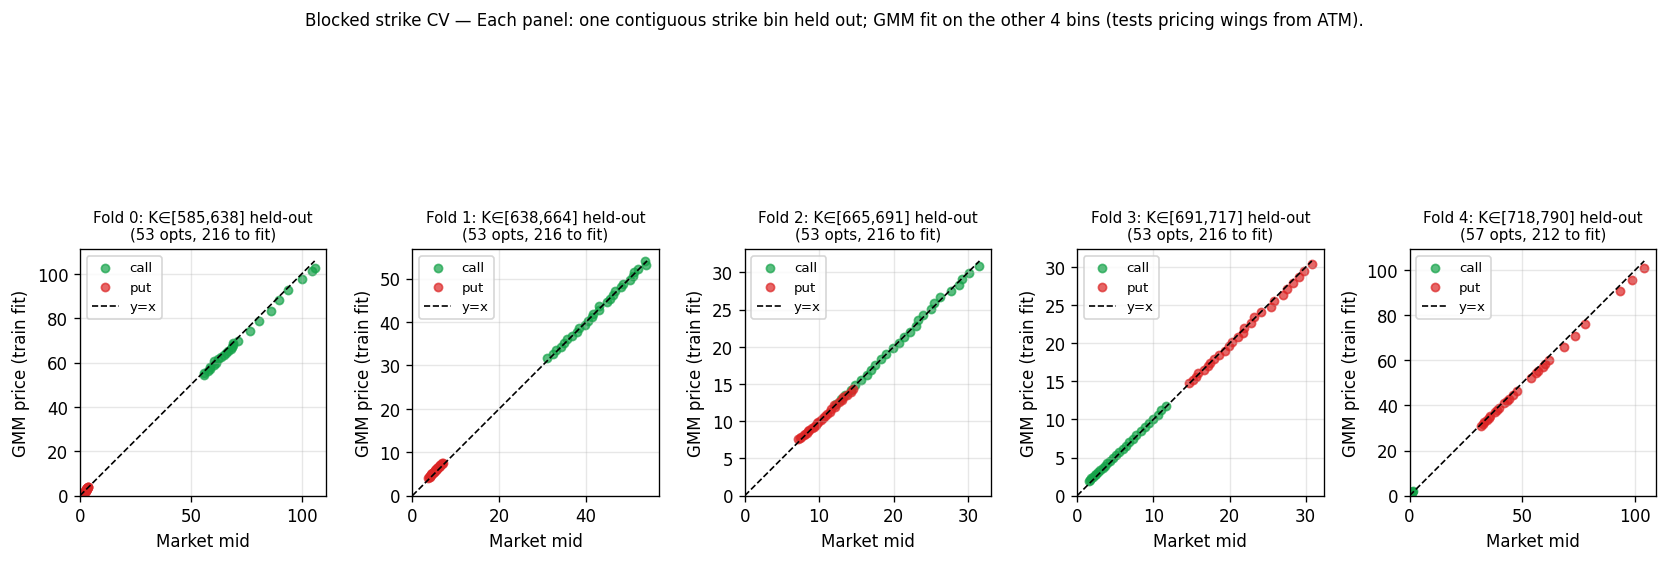

In [ ]:
# 4.2 Blocked strike CV: 5 contiguous bins by strike (tests wings-from-ATM)
K_folds_block = 5
compare_block = compare.sort_values(["strike"]).reset_index(drop=True).copy()
n_b = len(compare_block)
# Contiguous bins by strike: first 1/5 → fold 0 (low strikes), ..., last 1/5 → fold 4 (high strikes)
bin_size = n_b // K_folds_block
fold_ids_block = np.zeros(n_b, dtype=int)
for i in range(K_folds_block):
    start = i * bin_size
    end = (i + 1) * bin_size if i < K_folds_block - 1 else n_b
    fold_ids_block[start:end] = i

rows_block = []
w_list_block = []
val_dfs_block = []
for k in range(K_folds_block):
    train_df = compare_block[fold_ids_block != k]
    val_df = compare_block[fold_ids_block == k].copy()
    if len(val_df) == 0:
        continue
    w_k = _fit_gmm_weights_on_subset(train_df)
    w_list_block.append(w_k)
    rmse_gauss = float(np.sqrt(((val_df["our_price"] - val_df["market_mid"]) ** 2).mean()))
    mix_val_prices = [
        mixture_option_price(centers, probs_list, w_k, row["strike"], row["type"] == "call", r, T)
        for _, row in val_df.iterrows()
    ]
    val_df["mix_price_val"] = mix_val_prices
    val_dfs_block.append(val_df)
    rmse_mix = float(np.sqrt(((np.array(mix_val_prices) - val_df["market_mid"].values) ** 2).mean()))
    rows_block.append({"fold": k, "n_val": len(val_df), "rmse_gaussian_val": rmse_gauss, "rmse_mix_val": rmse_mix})

cv_block_df = pd.DataFrame(rows_block)
print("Blocked strike CV (5 contiguous strike bins):")
print(cv_block_df.to_string(index=False))
print("\nAverage validation RMSE (blocked strike):")
print(cv_block_df[["rmse_gaussian_val", "rmse_mix_val"]].mean().to_frame("mean_RMSE").to_string())

if w_list_block:
    w_mat_block = np.vstack(w_list_block)
    comp_index_block = [f"Comp {j+1}" for j in range(N_COMPONENTS)]
    w_summary_block = pd.DataFrame(
        {"mean": w_mat_block.mean(axis=0), "std": w_mat_block.std(axis=0)},
        index=comp_index_block,
    )
    print("\nBlocked strike: mixture weight stability across folds (mean ± std):")
    print(w_summary_block.round(4).to_string())

# Labels for which region each fold is (low strike → put wing, high strike → call wing)
strike_ranges = [(val_dfs_block[k]["strike"].min(), val_dfs_block[k]["strike"].max()) for k in range(len(val_dfs_block))]
n_total_b = len(compare_block)
fig_block, axes = plt.subplots(1, 5, figsize=(14, 5.5))
for k, ax in enumerate(axes):
    v = val_dfs_block[k]
    n_train = n_total_b - len(v)
    lo, hi = strike_ranges[k][0], strike_ranges[k][1]
    for opt_type, color in [("call", "#16a34a"), ("put", "#dc2626")]:
        sub = v[v["type"] == opt_type]
        if len(sub) > 0:
            ax.scatter(sub["market_mid"], sub["mix_price_val"], alpha=0.7, s=24, c=color, label=opt_type)
    mx = max(v["market_mid"].max(), v["mix_price_val"].max()) if len(v) > 0 else 1
    ax.plot([0, mx], [0, mx], "k--", linewidth=1, label="y=x")
    ax.set_xlabel("Market mid")
    ax.set_ylabel("GMM price (train fit)")
    ax.set_title(f"Fold {k}: K∈[{lo:.0f},{hi:.0f}] held-out\n({len(v)} opts, {n_train} to fit)", fontsize=9)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_aspect("equal")
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
plt.suptitle(
    "Blocked strike CV — Each panel: one contiguous strike bin held out; "
    "GMM fit on the other 4 bins (tests pricing wings from ATM).",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

---
## 4. Visualizations

### Payoff curves (why OTM options are harder to price)

Option value in our model = **discounted expected payoff at expiration**: $e^{-rT} \mathbb{E}[\text{payoff}(S_T)]$. The **payoff at expiration** is $\max(S_T - K, 0)$ (call) or $\max(K - S_T, 0)$ (put). Below we plot these payoff curves for several strikes.

**Intrinsic vs extrinsic:** We are *not* using **intrinsic value** (value if exercised *today*: $\max(S_0 - K, 0)$ for a call). We use the **terminal** payoff at $T$ and take the expectation over $S_T$. That expectation *does* include **time value**: because $S_T$ is uncertain, $\mathbb{E}[\max(S_T - K, 0)]$ can be much larger than $\max(S_0 - K, 0)$ for OTM/ATM options. So we are capturing European-style time value, not “only intrinsic.”

**European vs American:** We are pricing **European** options (exercise only at $T$). Listed US options (e.g. SPY) are **American** (exercise any time). For **calls** on low-dividend underlyings, American ≈ European (early exercise is rarely optimal). For **puts**, American can be worth *more* than European (early exercise premium when deep ITM or rates high). So our European formula can **systematically undervalue puts** relative to market — which matches the bias you’re seeing (puts undervalued → inflated put expected returns). Improving the left-tail of the GMM helps the European value; closing the remaining gap would require an American put pricer (e.g. tree or PDE).

The **value** under our model is $e^{-rT} \sum_{\text{buckets}} \text{payoff}(S) \times P(S \text{ in bucket})$ — so probability mass in the **wing** matters a lot for OTM options. If the GMM puts too little mass in the left tail, OTM puts are undervalued; too little in the right tail, OTM calls are undervalued.

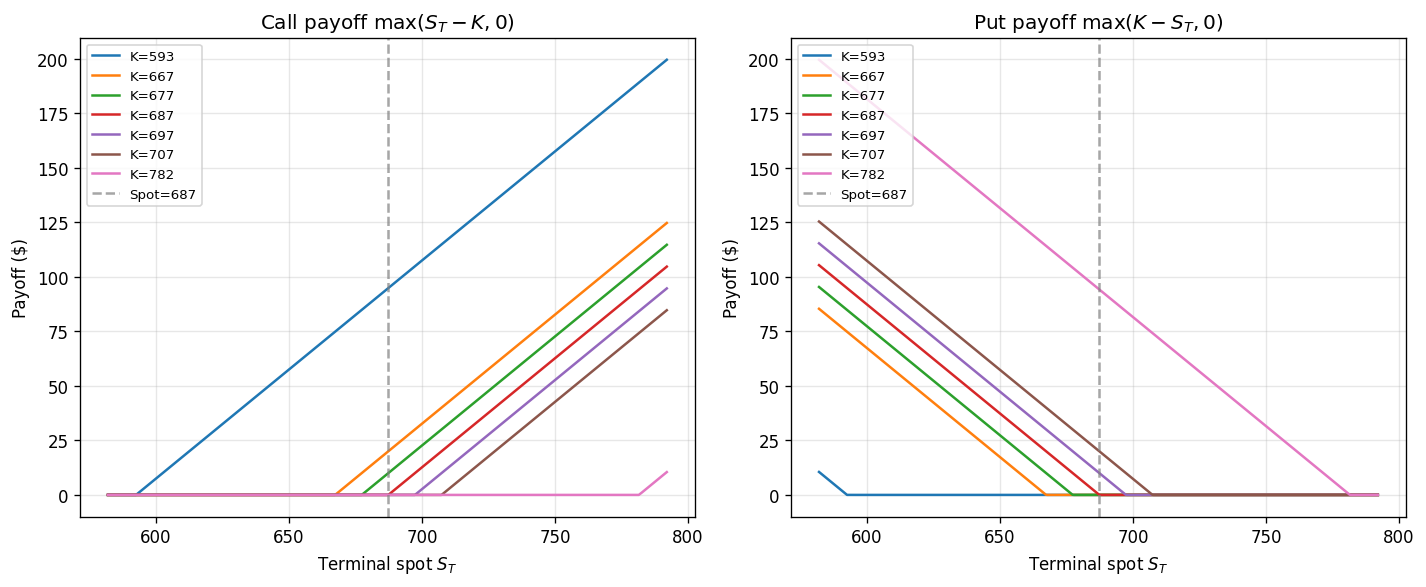

In [ ]:
# Fine grid for smooth payoff curves (terminal spot S_T)
S_grid = np.linspace(centers.min(), centers.max(), 400)
# Pick a few strikes: below spot (ITM calls / OTM puts), ATM, above spot (OTM calls / ITM puts)
strikes_plot = np.unique([
    centers.min() + 0.1 * (spot - centers.min()),
    spot - 20, spot - 10, spot, spot + 10, spot + 20,
    centers.max() - 0.1 * (centers.max() - spot)
])
strikes_plot = strikes_plot[(strikes_plot >= centers.min()) & (strikes_plot <= centers.max())][:7]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Calls: payoff = max(S - K, 0)
for K in strikes_plot:
    pay = np.maximum(S_grid - K, 0.0)
    ax1.plot(S_grid, pay, label=f"K={K:.0f}")
ax1.axvline(spot, color="gray", linestyle="--", alpha=0.7, label=f"Spot={spot:.0f}")
ax1.set_xlabel("Terminal spot $S_T$")
ax1.set_ylabel("Payoff ($)")
ax1.set_title("Call payoff $\\max(S_T - K, 0)$")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)

# Puts: payoff = max(K - S, 0)
for K in strikes_plot:
    pay = np.maximum(K - S_grid, 0.0)
    ax2.plot(S_grid, pay, label=f"K={K:.0f}")
ax2.axvline(spot, color="gray", linestyle="--", alpha=0.7, label=f"Spot={spot:.0f}")
ax2.set_xlabel("Terminal spot $S_T$")
ax2.set_ylabel("Payoff ($)")
ax2.set_title("Put payoff $\\max(K - S_T, 0)$")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# Display in notebook (avoids "FigureCanvasAgg is non-interactive" when plt.show() runs in some kernels)
try:
    from IPython.display import display
    display(fig)
except Exception:
    plt.show()
plt.close(fig)

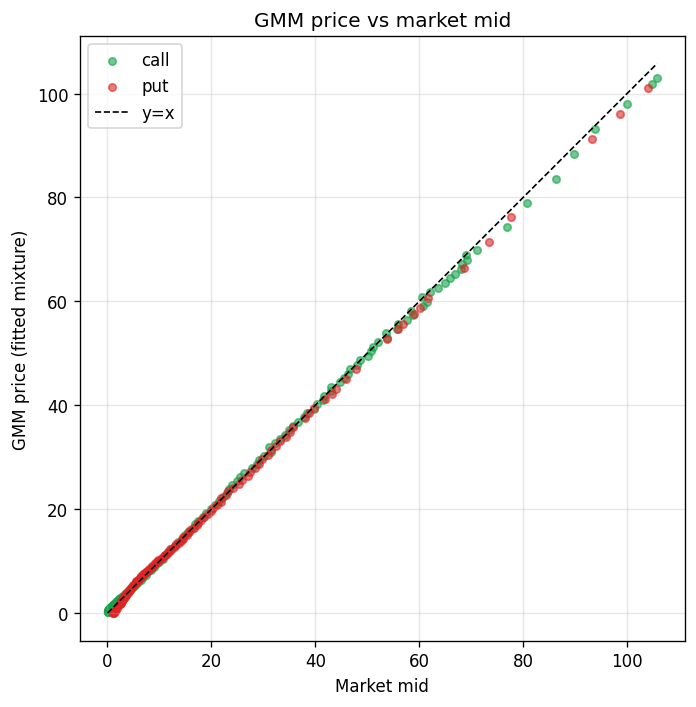

In [ ]:
# 2) GMM price vs market mid (scatter)
fig, ax = plt.subplots(figsize=(7, 6))
for opt_type, color in [("call", "#16a34a"), ("put", "#dc2626")]:
    sub = compare[compare["type"] == opt_type]
    ax.scatter(sub["market_mid"], sub["mix_price"], alpha=0.6, s=20, c=color, label=opt_type)
mx = max(compare["market_mid"].max(), compare["mix_price"].max())
ax.plot([0, mx], [0, mx], "k--", linewidth=1, label="y=x")
ax.set_xlabel("Market mid")
ax.set_ylabel("GMM price (fitted mixture)")
ax.set_title("GMM price vs market mid")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# 3) ATM slice: our price vs market
atm_band = spot * 0.05
atm = compare[(compare["strike"] >= spot - atm_band) & (compare["strike"] <= spot + atm_band)]
atm = atm.sort_values(["type", "strike"])
print("ATM slice (|strike - spot| <= 5% of spot):")
display(atm.round(4))

ATM slice (|strike - spot| <= 5% of spot):


,strike,type,market_mid,our_price,diff,diff_pct,mix_price,mix_diff,mix_diff_pct
41,653.0,call,41.410,35.3578,-6.0522,-0.1462,41.0194,-0.3906,-0.0094
42,654.0,call,40.370,34.4611,-5.9089,-0.1464,40.1799,-0.1901,-0.0047
43,655.0,call,39.825,33.5711,-6.2539,-0.1570,39.3423,-0.4827,-0.0121
44,656.0,call,38.390,32.6882,-5.7018,-0.1485,38.5067,0.1167,0.0030
45,657.0,call,37.885,31.8127,-6.0723,-0.1603,37.6731,-0.2119,-0.0056
...,...,...,...,...,...,...,...,...,...
242,717.0,put,30.805,31.2049,0.3999,0.0130,30.4597,-0.3453,-0.0112
243,718.0,put,31.500,32.0750,0.5750,0.0183,31.3137,-0.1863,-0.0059
244,719.0,put,32.445,32.9527,0.5077,0.0156,32.1795,-0.2655,-0.0082
245,720.0,put,33.165,33.8378,0.6728,0.0203,33.0561,-0.1089,-0.0033


Summary statistics (GMM mix_price vs market_mid):
      count  mean_diff  mean_abs_diff  median_abs_diff_pct
type                                                      
call    137  -0.101145       0.498584             0.018361
put     132  -0.223487       0.484409             0.022808

(median_abs_diff_pct = median of |mix_diff_pct|; robust when market_mid is small)


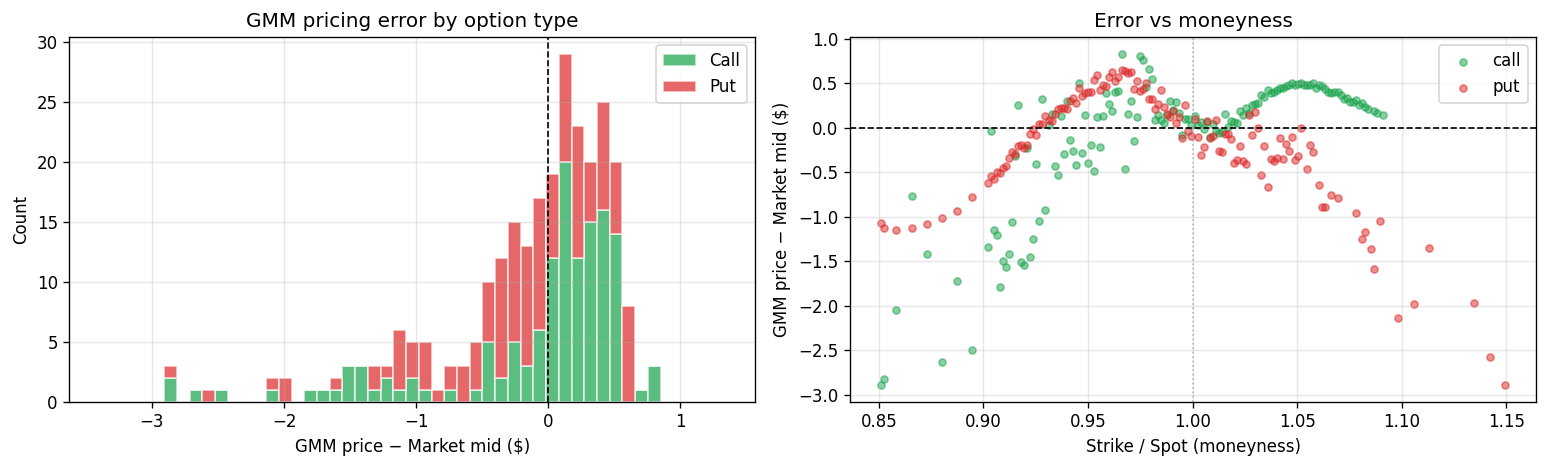

In [ ]:
print("Summary statistics (GMM mix_price vs market_mid):")
summary = compare.groupby("type").agg(
    count=("market_mid", "count"),
    mean_diff=("mix_diff", "mean"),
    mean_abs_diff=("mix_diff", lambda s: s.abs().mean()),
    median_abs_diff_pct=("mix_diff_pct", lambda s: s.abs().median()),
).round(6)
print(summary.to_string())
print("\n(median_abs_diff_pct = median of |mix_diff_pct|; robust when market_mid is small)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked histogram by type
bins = np.linspace(compare["mix_diff"].min() - 0.5, compare["mix_diff"].max() + 0.5, 50)
call_diff = compare.loc[compare["type"] == "call", "mix_diff"]
put_diff = compare.loc[compare["type"] == "put", "mix_diff"]
axes[0].hist([call_diff, put_diff], bins=bins, alpha=0.7,
             color=["#16a34a", "#dc2626"], label=["Call", "Put"],
             edgecolor="white", stacked=True)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("GMM price − Market mid ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("GMM pricing error by option type")
axes[0].legend()

# Right: error vs moneyness (strike / spot)
for opt_type, color in [("call", "#16a34a"), ("put", "#dc2626")]:
    sub = compare[compare["type"] == opt_type]
    moneyness = sub["strike"] / spot
    axes[1].scatter(moneyness, sub["mix_diff"], alpha=0.5, s=18, c=color, label=opt_type)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(1.0, color="gray", linestyle=":", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Strike / Spot (moneyness)")
axes[1].set_ylabel("GMM price − Market mid ($)")
axes[1].set_title("Error vs moneyness")
axes[1].legend()

plt.tight_layout()
plt.show()

### Why the GMM errors look bimodal (and what drives them)

The histogram above shows a characteristic pattern: **calls tend toward positive errors** (GMM overprices) while **puts tend toward negative errors** (GMM underprices). This is not a bug — it reflects a fundamental limitation of the 4-component Gaussian mixture.

**Root causes:**

1. **Only 4 free parameters vs ~260 options.** The GMM components have fixed means and standard deviations (set from realized vol). Only the 4 mixture weights are fitted. This is an extremely parsimonious model: 4 degrees of freedom to match ~260 market prices. A perfect fit is mathematically impossible; the optimizer finds a least-squares compromise.

2. **Insufficient left skew.** Real risk-neutral distributions have pronounced left skew — the market prices crash protection (OTM puts) more aggressively than a Gaussian mixture centered at spot can capture. Our 4 components are roughly symmetric: G1 and G2 are centered at spot, G3 is shifted right, G4 shifted left — but a single shifted-left Gaussian doesn't reproduce the fat left tail the market implies. The result: **puts are systematically underpriced** by the model (negative `mean_diff`) because the model's left tail is too thin, and **calls are slightly overpriced** because the optimizer compensates by fattening the right side to reduce total SSE.

3. **Realized vol ≠ implied vol.** The component widths use 2-month realized volatility. If realized vol is lower than the market's implied vol (the usual case), the model distribution is too narrow, creating a "smile" mismatch — underpricing wings on both sides, with the put side hit harder due to skew.

4. **Historical data quality.** For historical chain dates, `market_mid` comes from the option's daily close price (Alpaca bars), not a live bid-ask midpoint. End-of-day option closes can be stale (last trade could be hours old at a different underlying price), adding noise that the model can't fit regardless of its flexibility.

The right-hand scatter plot shows that the largest errors are concentrated in the **wings** (low moneyness for calls, high moneyness for puts) — exactly where skew matters most and where a simple Gaussian mixture struggles.

**How to improve the fit:**
- Allow the component means and variances to be **free parameters** (not just the weights) — this gives more flexibility to capture skew.
- Add more components (e.g. 6–8 Gaussians), especially one with a fat left tail.
- Use **implied volatility** rather than realized vol to set the initial component widths.
- Use higher-quality market data (live bid-ask mids vs stale closes) when available.

---
## 5. GMM sampling: expected returns and covariance

We sample from the **same single GMM** fitted above (one distribution for $S_T$, fit using all options). Each draw is a terminal spot $S_T$; from it we can compute payoffs (and returns) for any option. Here we do **100,000** draws and compute returns for four assets:
- **Underlying**: $(S_T - S_0) / S_0$
- **One call** (strike closest to spot): $(\\max(S_T - K, 0) - C_0) / C_0$ where $C_0$ is the GMM model price for that option
- **One put** (strike closest to spot): $(\\max(K - S_T, 0) - P_0) / P_0$ where $P_0$ is the GMM model price  
- **Cash**: $e^{rT} - 1$ (risk-free over $T$)

The **time period** for all returns (including cash) is from **chain date to expiry**: $T$ years = DTE/365. So when the chosen expiry had **DTE = 35** (e.g. target DTE=14 but closest expiry was 35 days out), $T \approx 0.096$ yrs and cash return $e^{rT}-1 \approx 0.48\%$. Cash has a return because we are simulating over that holding period to expiry, not "today only."

So we use **one** GMM to simulate $S_T$, then from each $S_T$ we get the payoff for our chosen call and put. We report **expected returns** and the **covariance** and **correlation** matrices of these four assets.

In [ ]:
# GMM component parameters (same as used for mixture pricing)
# The GMM was fitted on len(compare) options (all calls + puts in the chain that passed filters).
n_options_fit = len(compare)
print(f"GMM was fitted on {n_options_fit} options (calls + puts across strikes).")

# Use the flexible GMM parameters fitted above
n_components = len(means_gmm)

n_samples = 100_000
np.random.seed(42)
# Sample component index, then S_T from that component
comp = np.random.choice(n_components, size=n_samples, p=w_fit)
S_T = np.random.normal(means_gmm[comp], sigmas_gmm[comp])

# We use one call and one put (ATM) because the portfolio has 4 assets: underlying, call, put, cash.
# The return/covariance stats are for that 4-asset universe; we pick the ATM strike as the single "call" and "put" asset.
# Pick one call and one put: strike closest to spot
call_df = compare[compare["type"] == "call"]
put_df = compare[compare["type"] == "put"]
K_call = call_df.loc[(call_df["strike"] - spot).abs().idxmin(), "strike"]
K_put = put_df.loc[(put_df["strike"] - spot).abs().idxmin(), "strike"]
C0 = float(compare[(compare["type"] == "call") & (compare["strike"] == K_call)]["mix_price"].iloc[0])
P0 = float(compare[(compare["type"] == "put") & (compare["strike"] == K_put)]["mix_price"].iloc[0])

# Returns (per scenario)
R_underlying = (S_T - spot) / spot
payoff_call = np.maximum(S_T - K_call, 0.0)
payoff_put = np.maximum(K_put - S_T, 0.0)
R_call = (payoff_call - C0) / C0
R_put = (payoff_put - P0) / P0
R_cash = np.exp(r * T) - 1.0  # same for all (deterministic)

# Stack into (n_samples, 4): underlying, call, put, cash
returns = np.column_stack([R_underlying, R_call, R_put, np.full(n_samples, R_cash)])
asset_names = ["underlying", "call", "put", "cash"]

print("Expected returns (GMM, 100_000 samples):")
print(pd.Series(returns.mean(axis=0), index=asset_names).to_string())
print(f"\nReference: call K={K_call:.0f} (GMM price={C0:.3f}), put K={K_put:.0f} (GMM price={P0:.3f})")

# Model vs market: compare GMM price to market mid for the options used in returns
market_call = float(compare[(compare["type"] == "call") & (compare["strike"] == K_call)]["market_mid"].iloc[0])
market_put = float(compare[(compare["type"] == "put") & (compare["strike"] == K_put)]["market_mid"].iloc[0])
model_vs_market = pd.DataFrame({
    "option": [f"call K={K_call:.0f}", f"put K={K_put:.0f}"],
    "market_mid": [market_call, market_put],
    "model_price": [C0, P0],
    "diff": [C0 - market_call, P0 - market_put],
    "diff_pct": [(C0 - market_call) / market_call, (P0 - market_put) / market_put],
})
print("\nModel price vs market (options used for return stats):")
print(model_vs_market.to_string(index=False))

# Covariance and correlation: exclude cash (zero variance) to avoid singular/unstable matrices.
# Winsorize risky-asset returns so a few crash scenarios don't dominate (e.g. put return >> 1).
returns_risk = returns[:, :3].copy()  # underlying, call, put
for j in range(3):
    lo, hi = np.nanpercentile(returns_risk[:, j], [1.0, 99.0])
    returns_risk[:, j] = np.clip(returns_risk[:, j], lo, hi)
asset_names_risk = ["underlying", "call", "put"]
cov = np.cov(returns_risk.T)
corr = np.corrcoef(returns_risk.T)

print("\nCovariance matrix (risky assets only; returns winsorized at 1st/99th pct):")
print(pd.DataFrame(cov, index=asset_names_risk, columns=asset_names_risk).round(6).to_string())
print("\nCorrelation matrix (risky assets only):")
print(pd.DataFrame(corr, index=asset_names_risk, columns=asset_names_risk).round(4).to_string())

GMM was fitted on 269 options (calls + puts across strikes).
Expected returns (GMM, 100_000 samples):
underlying   -0.008677
call          0.010637
put           0.552845
cash          0.004806

Reference: call K=687 (GMM price=14.295), put K=687 (GMM price=12.919)

Model price vs market (options used for return stats):
    option  market_mid  model_price      diff  diff_pct
call K=687      14.265    14.294844  0.029844  0.002092
 put K=687      13.010    12.918698 -0.091302 -0.007018

Covariance matrix (risky assets only; returns winsorized at 1st/99th pct):
            underlying      call        put
underlying    0.005754  0.054420  -0.245920
call          0.054420  1.231267  -1.533052
put          -0.245920 -1.533052  11.387995

Correlation matrix (risky assets only):
            underlying    call     put
underlying      1.0000  0.6466 -0.9607
call            0.6466  1.0000 -0.4094
put            -0.9607 -0.4094  1.0000


---
## 6. Single-period robustness test: GMM predictions vs reality

**Goal:** For **one period** of ~35 days (the most recent chain date ~35 days ago → today), fit the flexible GMM to that day's option chain, sample 100,000 terminal spots, and compute:
- **Predicted expected returns** (μ) and **predicted covariance** (Σ) from the samples — one return per sample for each of [underlying, ATM call, ATM put, cash]
- **Predicted vol** per asset = √diag(Σ)

Then compare to **what actually happened** over those 35 days:
- **Realized underlying return**: (spot_today − spot_entry) / spot_entry
- **Realized call/put return**: (intrinsic payoff at expiry − entry price) / entry price (using market mid at entry)
- **Realized underlying vol**: daily realized vol over the period, scaled to period length

This is a simple sanity check: if the GMM is reasonable, the realized return should fall somewhere plausible within the predicted distribution (not at 0.01th or 99.99th percentile), and the predicted vol should be in the same ballpark as realized vol.

**Note:** The GMM $\\Sigma_t$ is the covariance of **returns to expiry** (horizon $T$). The realized returns are **per rebalance interval** (chain date to next chain date). So mean predicted vol and realized vol may differ in level; the scatter (predicted vol vs |realized return|) still shows whether the model’s *relative* volatility predictions line up with outcomes.

In [9]:
# §6 — Single-period robustness test: predicted (GMM 100k samples) vs realized
#
# Pick a chain date ~35 days before today, fit the flexible GMM, sample 100k terminal
# spots, compute predicted expected returns and covariance. Then look at what *actually*
# happened over those 35 days and compare.

import os
import re
from scipy.optimize import brentq
from data.gmm_forecasts import _build_compare_and_fit_gmm
from data.forecasts import _bs_call_price, _bs_put_price
from config import OPTION_CHAINS_DIR, SPY_DAILY_FILE

ASSET_NAMES = ["underlying", "call", "put", "cash"]
N_SAMPLES = 100_000
HOLDING_DAYS_TARGET = 35

# --- 1) Find the chain date closest to 35 days ago ---
spy_df_bt = pd.read_parquet(SPY_DAILY_FILE)
spy_df_bt.index = pd.to_datetime(spy_df_bt.index).tz_localize(None).normalize()

all_files = sorted(os.listdir(OPTION_CHAINS_DIR))
chain_dates_all = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_files
    if f.startswith("calls_") or f.startswith("puts_")
})
today = pd.Timestamp.now().normalize()
target_entry = today - pd.Timedelta(days=HOLDING_DAYS_TARGET)
entry_date = min(chain_dates_all, key=lambda d: abs((pd.Timestamp(d) - target_entry).days))
entry_ts = pd.Timestamp(entry_date)
holding_days = (today - entry_ts).days
print(f"Entry date: {entry_date}  (today={today.date()}, holding={holding_days} days)", flush=True)

# --- 2) Get spot at entry ---
idx = spy_df_bt.index.get_indexer([entry_ts], method="ffill")[0]
spot_entry = float(spy_df_bt.iloc[idx]["close"])

# --- 3) Fit GMM on entry-date chain, get model prices ---
compare, w_fit_bt, means_gmm_bt, sigmas_gmm_bt, T_bt, r_bt, expiry_used_bt = \
    _build_compare_and_fit_gmm(entry_date, spot_entry, spy_df_bt, r=0.05, underlying="SPY")
print(f"Expiry: {expiry_used_bt}  T={T_bt:.4f} yrs ({T_bt*365:.0f} days)", flush=True)
print(f"Fitted {len(means_gmm_bt)}-component GMM on {len(compare)} options", flush=True)
for j in range(len(means_gmm_bt)):
    print(f"  Comp {j+1}: mu={means_gmm_bt[j]:.1f}  sigma={sigmas_gmm_bt[j]:.1f}  w={w_fit_bt[j]:.4f}", flush=True)

# ATM call/put
call_df_bt = compare[compare["type"] == "call"]
put_df_bt = compare[compare["type"] == "put"]
K_call_bt = call_df_bt.loc[(call_df_bt["strike"] - spot_entry).abs().idxmin(), "strike"]
K_put_bt = put_df_bt.loc[(put_df_bt["strike"] - spot_entry).abs().idxmin(), "strike"]
C0 = float(compare[(compare["type"] == "call") & (compare["strike"] == K_call_bt)]["mix_price"].iloc[0])
P0 = float(compare[(compare["type"] == "put") & (compare["strike"] == K_put_bt)]["mix_price"].iloc[0])
C0_mkt = float(compare[(compare["type"] == "call") & (compare["strike"] == K_call_bt)]["market_mid"].iloc[0])
P0_mkt = float(compare[(compare["type"] == "put") & (compare["strike"] == K_put_bt)]["market_mid"].iloc[0])
print(f"\nATM call K={K_call_bt:.0f}: GMM model={C0:.3f}, market={C0_mkt:.3f}", flush=True)
print(f"ATM put  K={K_put_bt:.0f}: GMM model={P0:.3f}, market={P0_mkt:.3f}", flush=True)

# --- 4) Sample 100k from GMM → predicted returns, μ, Σ ---
np.random.seed(42)
n_comp_bt = len(means_gmm_bt)
comp_idx = np.random.choice(n_comp_bt, size=N_SAMPLES, p=w_fit_bt)
S_T_samples = np.random.normal(means_gmm_bt[comp_idx], sigmas_gmm_bt[comp_idx])

R_und_pred = (S_T_samples - spot_entry) / spot_entry
R_call_pred = (np.maximum(S_T_samples - K_call_bt, 0.0) - C0) / C0
R_put_pred = (np.maximum(K_put_bt - S_T_samples, 0.0) - P0) / P0
R_cash_pred = np.full(N_SAMPLES, np.exp(r_bt * T_bt) - 1.0)

returns_pred = np.column_stack([R_und_pred, R_call_pred, R_put_pred, R_cash_pred])
mu_pred = returns_pred.mean(axis=0)
Sigma_pred = np.cov(returns_pred, rowvar=False)
vol_pred = np.sqrt(np.maximum(np.diag(Sigma_pred), 0.0))

# --- 5) Realized: what actually happened ---
# Spot today (or nearest available close)
idx_today = spy_df_bt.index.get_indexer([today], method="ffill")[0]
spot_today = float(spy_df_bt.iloc[idx_today]["close"])

# Realized underlying return over the period
R_und_real = (spot_today - spot_entry) / spot_entry

# Realized call/put return: intrinsic payoff at expiry (or at today if before expiry) minus entry cost
# If expiry has passed, use intrinsic at expiry (spot on expiry date).
# If expiry is still ahead, use today's spot as approximation.
expiry_ts = pd.Timestamp(expiry_used_bt)
if expiry_ts <= today:
    idx_exp = spy_df_bt.index.get_indexer([expiry_ts], method="ffill")[0]
    spot_at_exp = float(spy_df_bt.iloc[idx_exp]["close"])
    label = f"(at expiry {expiry_used_bt})"
else:
    spot_at_exp = spot_today
    label = f"(at today, expiry {expiry_used_bt} not yet reached)"
R_call_real = (max(spot_at_exp - K_call_bt, 0.0) - C0_mkt) / C0_mkt
R_put_real = (max(K_put_bt - spot_at_exp, 0.0) - P0_mkt) / P0_mkt
R_cash_real = np.exp(r_bt * holding_days / 365.0) - 1.0

mu_real = np.array([R_und_real, R_call_real, R_put_real, R_cash_real])

# --- Realized covariance and vol from DAILY data over the period ---
# Get ATM IV at entry (invert BS from market call price) for marking options each day
def _iv_objective(sig):
    return _bs_call_price(spot_entry, K_call_bt, r_bt, T_bt, sig) - C0_mkt
try:
    iv_atm = float(brentq(_iv_objective, 0.01, 2.0))
except Exception:
    iv_atm = 0.15

# Slice SPY for every trading day in [entry_ts, today]
spy_slice = spy_df_bt.loc[entry_ts:today]["close"]
dates_slice = spy_slice.index
spots = spy_slice.values.astype(float)
n_dates = len(spots)
if n_dates < 2:
    raise ValueError("Need at least 2 trading days in the period for daily realized cov")

# For each date, T_remain and option value (BS or intrinsic if expired)
T_remain_arr = np.array([max((expiry_ts - d).days / 365.0, 1e-6) for d in dates_slice])
call_vals = np.zeros(n_dates)
put_vals = np.zeros(n_dates)
for i in range(n_dates):
    if T_remain_arr[i] > 1 / 365.0:
        call_vals[i] = max(_bs_call_price(spots[i], K_call_bt, r_bt, T_remain_arr[i], iv_atm), 0.01)
        put_vals[i] = max(_bs_put_price(spots[i], K_put_bt, r_bt, T_remain_arr[i], iv_atm), 0.01)
    else:
        call_vals[i] = max(spots[i] - K_call_bt, 0.01)
        put_vals[i] = max(K_put_bt - spots[i], 0.01)

# Daily returns (n_dates - 1 rows)
r_und_d = (spots[1:] - spots[:-1]) / spots[:-1]
r_call_d = (call_vals[1:] - call_vals[:-1]) / call_vals[:-1]
r_put_d = (put_vals[1:] - put_vals[:-1]) / put_vals[:-1]
r_cash_d = (np.exp(r_bt / 365.0) - 1.0) * np.ones(n_dates - 1)

R_daily = np.column_stack([r_und_d, r_call_d, r_put_d, r_cash_d])
n_days = R_daily.shape[0]

# Period-scale realized cov and vol (under iid daily: var(sum) = n_days * var(daily))
Sigma_real_daily = np.cov(R_daily, rowvar=False)
Sigma_real = n_days * Sigma_real_daily
vol_real = np.std(R_daily, axis=0) * np.sqrt(n_days)
# Ensure cash vol is exactly 0 for display
vol_real[3] = 0.0
Sigma_real[3, :] = 0.0
Sigma_real[:, 3] = 0.0
Sigma_real[3, 3] = 1e-12

# --- 6) Print comparison ---
print(f"\n{'='*70}", flush=True)
print(f"SINGLE-PERIOD TEST: {entry_date} → {today.date()} ({holding_days} days)", flush=True)
print(f"Entry spot: {spot_entry:.2f}    Today's spot: {spot_today:.2f}    Expiry spot: {spot_at_exp:.2f} {label}", flush=True)
print(f"{'='*70}", flush=True)

print(f"\n--- Predicted vs realized expected returns ---", flush=True)
df_mu = pd.DataFrame({
    "asset": ASSET_NAMES,
    "predicted_E[R]": mu_pred,
    "realized_R": mu_real,
    "diff": mu_pred - mu_real,
})
print(df_mu.to_string(index=False), flush=True)

print(f"\n--- Predicted vs realized std (vol) per asset ---", flush=True)
print(f"  (Realized from daily returns over {n_days} days; period vol = std(daily) × √n_days)", flush=True)
df_vol = pd.DataFrame({
    "asset": ASSET_NAMES,
    "predicted_vol": vol_pred,
    "realized_vol": vol_real,
    "ratio_pred_real": np.where(vol_real > 1e-12, vol_pred / vol_real, np.nan),
})
print(df_vol.to_string(index=False), flush=True)

print(f"\n--- Predicted covariance (from GMM 100k samples) ---", flush=True)
print(pd.DataFrame(Sigma_pred, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string(), flush=True)

print(f"\n--- Realized covariance (from daily returns over {n_days} days, scaled to period) ---", flush=True)
print("  Call/put marked daily via Black-Scholes (sticky IV from entry); period Σ = n_days × cov(daily).", flush=True)
print(pd.DataFrame(Sigma_real, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string(), flush=True)

print(f"\n--- Realized correlation ---", flush=True)
std_real = np.sqrt(np.maximum(np.diag(Sigma_real), 1e-20))
corr_real = Sigma_real / np.outer(std_real, std_real)
print(pd.DataFrame(corr_real, index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string(), flush=True)

print(f"\n--- Predicted correlation ---", flush=True)
std_diag = np.sqrt(np.maximum(np.diag(Sigma_pred), 1e-20))
corr_pred = Sigma_pred / np.outer(std_diag, std_diag)
print(pd.DataFrame(corr_pred, index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string(), flush=True)

# --- 7) Where did realized return fall in the predicted distribution? ---
print(f"\n--- Where realized falls in the predicted distribution ---", flush=True)
for i, name in enumerate(ASSET_NAMES[:3]):
    pctile = float(np.mean(returns_pred[:, i] <= mu_real[i]) * 100)
    print(f"  {name}: realized {mu_real[i]:+.4f} is at {pctile:.1f}th percentile of predicted distribution", flush=True)

Entry date: 2026-01-23  (today=2026-02-25, holding=33 days)
Expiry: 2026-02-27  T=0.0959 yrs (35 days)
Fitted 6-component GMM on 167 options
  Comp 1: mu=585.8  sigma=56.7  w=0.1671
  Comp 2: mu=723.3  sigma=14.0  w=0.1673
  Comp 3: mu=702.1  sigma=10.0  w=0.1663
  Comp 4: mu=678.2  sigma=10.0  w=0.1667
  Comp 5: mu=702.1  sigma=10.0  w=0.1662
  Comp 6: mu=702.2  sigma=10.0  w=0.1664

ATM call K=689: GMM model=12.889, market=12.700
ATM put  K=689: GMM model=10.479, market=10.320

SINGLE-PERIOD TEST: 2026-01-23 → 2026-02-25 (33 days)
Entry spot: 689.23    Today's spot: 693.10    Expiry spot: 693.10 (at today, expiry 2026-02-27 not yet reached)

--- Predicted vs realized expected returns ---
     asset  predicted_E[R]  realized_R      diff
underlying       -0.010060    0.005615 -0.015675
      call       -0.006908   -0.677165  0.670257
       put        0.861183   -1.000000  1.861183
      cash        0.004806    0.004531  0.000275

--- Predicted vs realized std (vol) per asset ---
  (Re

/var/folders/v7/fy28j8pd6yb_vb5vddcfccd00000gn/T/ipykernel_41070/3938183447.py:169: RuntimeWarning: divide by zero encountered in divide
  "ratio_pred_real": np.where(vol_real > 1e-12, vol_pred / vol_real, np.nan),


---
## 8. Portfolio performance illustration (GMM backtest)

Multi-panel view of the GMM Markowitz backtest: **value curve**, **drawdown**, and **weights over time**.

---
## 7. Two-year backtest: GMM-based μ and Σ at each rebalance (no sampling)

Same structure as `backtest.py`: rebalance on each chain date, but **forecasts** are GMM-based and **deterministic** (no Monte Carlo).

1. **Chain dates**: Use SPY chain dates from the last **2 years**.
2. **Realized returns**: Build period returns (SPY, ATM call, ATM put, cash) between consecutive chain dates using the same logic as `backtest.build_realized_returns`.
3. **At each rebalance** (entry date): Fit the 4-component GMM to that day's option chain (same least-squares fit as §4). Compute **μ** and **Σ** from the mixture **analytically** (no random sampling) via `data.gmm_forecasts.compute_gmm_forecasts`.
4. **Markowitz**: Solve mean–variance with these μ and Σ (same constraints as in backtest: long-only, sum=1, etc.).
5. **Compound**: Apply realized return to portfolio; repeat.

In [ ]:
# # Two-year backtest: GMM-based μ and Σ at each rebalance (deterministic, no sampling)
# import sys
# from pathlib import Path
# if str(Path.cwd()) not in sys.path:
#     sys.path.insert(0, str(Path.cwd()))

# from backtest import (
#     build_realized_returns,
#     _available_chain_dates,
#     _solve_markowitz,
#     _regularize_sigma,
# )
# from data.forecasts import ASSET_ORDER
# from data.gmm_forecasts import compute_gmm_forecasts
# from config import SPY_DAILY_FILE

# # Load SPY and get chain dates (last 2 years)
# spy_df = pd.read_parquet(SPY_DAILY_FILE)
# spy_df.index = pd.to_datetime(spy_df.index).tz_localize(None).normalize()
# chain_dates = _available_chain_dates("SPY")
# cutoff = pd.Timestamp.now().normalize() - pd.Timedelta(days=730)
# chain_dates_2y = sorted([d for d in chain_dates if pd.Timestamp(d) >= cutoff])
# if len(chain_dates_2y) < 2:
#     raise ValueError("Need at least 2 chain dates in last 2 years")

# returns = build_realized_returns(
#     chain_dates_2y, spy_df, asset_order=ASSET_ORDER, underlying="SPY"
# )
# n_periods = len(returns)
# n_assets = len(ASSET_ORDER)
# w_prev = np.array([0.6, 0.0, 0.0, 0.4])
# portfolio_values = [1.0]
# weights_history = [w_prev.copy()]
# gamma = 2.0
# spot_t = float(spy_df["close"].iloc[-1])  # fallback spot

# for t in range(n_periods):
#     entry_date = chain_dates_2y[t]
#     idx = spy_df.index.get_indexer([pd.Timestamp(entry_date)], method="ffill")[0]
#     if idx >= 0:
#         spot_t = float(spy_df.iloc[idx]["close"])
#     try:
#         mu_t, Sigma_t = compute_gmm_forecasts(
#             entry_date, spot_t, spy_df, r=0.05, underlying="SPY"
#         )
#         Sigma_t = _regularize_sigma(Sigma_t)
#     except Exception as e:
#         print(f"GMM failed {entry_date}: {e}; using fallback μ, Σ")
#         hold_days = (pd.Timestamp(chain_dates_2y[t + 1]) - pd.Timestamp(entry_date)).days if t + 1 < len(chain_dates_2y) else 7
#         r_period = np.exp(0.05 * hold_days / 365.0) - 1.0
#         mu_t = np.array([0.005, 0.0, 0.0, r_period])
#         Sigma_t = _regularize_sigma(np.diag([0.001, 0.1, 0.1, 1e-10]))
#     w_opt = _solve_markowitz(
#         mu_t, Sigma_t, w_prev,
#         gamma=gamma, max_port_vol=None, rho=None,
#         max_equity_weight=1.0, max_option_weight=0.05, min_cash_weight=0.0,
#     )
#     weights_history.append(w_opt)
#     r_vec = returns.iloc[t].values.astype(float)
#     port_ret = float(np.dot(w_opt, r_vec))
#     portfolio_values.append(portfolio_values[-1] * (1 + port_ret))
#     w_prev = w_opt

# dates_full = pd.DatetimeIndex([pd.Timestamp(chain_dates_2y[0])] + list(returns.index))
# portfolio_df = pd.DataFrame({"value": portfolio_values}, index=dates_full)
# weights_df = pd.DataFrame(weights_history, index=dates_full, columns=ASSET_ORDER)

# print(f"Backtest: {n_periods} periods, {dates_full[0].date()} → {dates_full[-1].date()}")
# print(f"Final portfolio value: {portfolio_values[-1]:.4f}")
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(portfolio_df.index, portfolio_df["value"], color="#2563eb", linewidth=1.5, label="Portfolio (GMM Markowitz)")
# ax.set_ylabel("Portfolio value")
# ax.set_title("Two-year backtest: GMM-based μ, Σ at each rebalance (no sampling)")
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# # Portfolio performance illustration (requires §7 backtest run)
# fig_perf, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 0.8, 1]})

# # 1) Portfolio value
# ax0 = axes[0]
# ax0.plot(portfolio_df.index, portfolio_df["value"], color="#2563eb", linewidth=2, label="GMM Markowitz portfolio")
# ax0.set_ylabel("Portfolio value")
# ax0.set_title("GMM backtest: portfolio value")
# ax0.legend(loc="upper left")
# ax0.set_ylim(0, None)
# ax0.grid(True, alpha=0.3)

# # 2) Drawdown
# ax1 = axes[1]
# cummax = portfolio_df["value"].cummax()
# drawdown = (portfolio_df["value"] - cummax) / cummax
# ax1.fill_between(portfolio_df.index, drawdown, 0, color="#dc2626", alpha=0.4)
# ax1.plot(portfolio_df.index, drawdown, color="#dc2626", linewidth=1)
# ax1.set_ylabel("Drawdown")
# ax1.set_title("Drawdown from peak")
# ax1.set_ylim(drawdown.min() - 0.01, 0.01)
# ax1.grid(True, alpha=0.3)

# # 3) Weights over time
# ax2 = axes[2]
# wcols = [c for c in weights_df.columns if c in ASSET_ORDER]
# wstack = weights_df[wcols].values
# x = portfolio_df.index
# ax2.stackplot(
#     x,
#     *[wstack[:, j] for j in range(len(wcols))],
#     labels=wcols,
#     colors=["#2563eb", "#16a34a", "#dc2626", "#f59e0b"],
#     alpha=0.85,
# )
# ax2.set_ylabel("Weight")
# ax2.set_xlabel("Date")
# ax2.set_title("Portfolio weights over time")
# ax2.legend(loc="upper right", ncol=4)
# ax2.set_ylim(0, 1)
# ax2.grid(True, alpha=0.3)

# plt.suptitle("GMM-based Markowitz backtest: performance illustration", fontsize=12, y=1.02)
# plt.tight_layout()
# plt.show()